Before we begin testing the teacher model on Validation set questions we first need to filter out subjects with low number of questions.


In [ ]:
import json

with open('/content/drive/MyDrive/Research Project Synthetic Data/Taxonomy/taxonomy (2).json') as f:
    taxonomy_full = json.load(f)

MIN_VALID = 50

taxonomy = {
    subj: data
    for subj, data in taxonomy_full.items()
    if data['valid_count'] >= MIN_VALID
}

dropped = {s: taxonomy_full[s]['valid_count']
           for s in taxonomy_full if s not in taxonomy}

print(f"Kept {len(taxonomy)} subjects, dropped {len(dropped)}")
print("Dropped (subject: valid_count):", dropped)

with open("taxonomy_filtered.json", "w") as f:
    json.dump(taxonomy, f, indent=2)

Kept 16 subjects, dropped 5
Dropped (subject: valid_count): {'anaesthesia': 34, 'orthopaedics': 20, 'psychiatry': 16, 'skin': 17, 'unknown': 2}


Checking if the question and their options get parsed properly

In [ ]:
import pandas as pd

valid = pd.read_json('/content/drive/MyDrive/Research Project Synthetic Data/data/dev.json', lines = True)
row = valid.iloc[0]

print('Question', row['question'])
print('A)', row['opa'])
print('B)', row['opb'])
print('C)', row['opc'])
print('D)', row['opd'])
print("\ncop value:", row['cop'])


Question Which of the following is not true for myelinated nerve fibers:
A) Impulse through myelinated fibers is slower than non-myelinated fibers
B) Membrane currents are generated at nodes of Ranvier
C) Saltatory conduction of impulses is seen
D) Local anesthesia is effective only when the nerve is not covered by myelin sheath

cop value: 1


Putting one question through the API and getting the raw response

In [ ]:
from google import genai
from google.genai import types
from google.colab import userdata
API_KEY = userdata.get('Teachermodel')
client = genai.Client(api_key=API_KEY)
MODEL_ID = 'gemini-3.5-flash'

prompt = f'''Answer this medical multiple choice question. Reply with ONLY the letter (A, B, C, or D).
Question: {row['question']}

A) {row['opa']}
B) {row['opb']}
C) {row['opc']}
D) {row['opd']}

Answer:'''

resp = client.models.generate_content(
    model = MODEL_ID,
    contents = prompt,
    config = types.GenerateContentConfig(temperature= 0.0,
                                         max_output_tokens= 1000,
                                         thinking_config=types.ThinkingConfig(thinking_budget=0))
    )
print('RAW RESPONSE', repr(resp.text))

RAW RESPONSE 'A'


Adding the parser and scoring logic

In [ ]:
OPTION_LETTER = ['A', 'B', 'C', 'D']

def parse_answer(text):
  for ch in text.upper():
    if ch in 'ABCD':
      return ch
  return None

pred = parse_answer(resp.text)
true = OPTION_LETTER[int(row['cop']) - 1]

print(f"Predicted: {pred} | True: {true} | Correct: {pred == true}")

Predicted: A | True: A | Correct: True


Testing five questions as a loop

In [ ]:
import time

def ask_and_score(row):
  prompt = f'''Answer this medical multiple choice question. Reply with ONLY the letter (A, B, C, or D).

  Question: {row['question']}

  A) {row['opa']}
  B) {row['opb']}
  D) {row['opc']}
  D) {row['opd']}

  Answer:'''

  resp = client.models.generate_content(
      model = MODEL_ID,
      contents = prompt,
      config = types.GenerateContentConfig(temperature= 0.0,
                                         max_output_tokens= 1000,
                                         thinking_config=types.ThinkingConfig(thinking_budget=0))
  )
  raw = resp.text.strip()
  pred = parse_answer(raw)
  true = OPTION_LETTER[int(row['cop']) - 1]
  return raw, pred, true


for _, r in valid.head(5).iterrows():
  raw, pred, true = ask_and_score(r)
  print(f'raw = {repr(raw):20} pred = {pred} true = {true} correct = {pred == true}')
  time.sleep(1)

raw = 'A'                  pred = A true = A correct = True
raw = 'D'                  pred = D true = A correct = False
raw = 'C'                  pred = C true = C correct = True
raw = 'C'                  pred = C true = C correct = True
raw = 'A'                  pred = A true = A correct = True


testing one question per subject

In [ ]:
with open('/content/drive/MyDrive/Research Project Synthetic Data/Taxonomy/taxonomy_filtered.json') as f:
    taxonomy = json.load(f)
subjects = list(taxonomy.keys())

valid['subject_name'] = valid['subject_name'].str.strip().str.lower()

for subject in subjects:
    subj_qs = valid[valid['subject_name'] == subject].sample(n=1, random_state=42)
    r = subj_qs.iloc[0]
    raw, pred, true = ask_and_score(r)
    print(f"{subject:25} pred={pred} true={true} correct={pred==true}")
    time.sleep(1)

anatomy                   pred=B true=B correct=True
biochemistry              pred=A true=A correct=True
dental                    pred=B true=B correct=True
ent                       pred=C true=C correct=True
forensic medicine         pred=A true=A correct=True
gynaecology & obstetrics  pred=C true=C correct=True
medicine                  pred=D true=C correct=False
microbiology              pred=C true=C correct=True
ophthalmology             pred=A true=A correct=True
pathology                 pred=B true=B correct=True
pediatrics                pred=C true=C correct=True
pharmacology              pred=A true=A correct=True
physiology                pred=A true=A correct=True
radiology                 pred=B true=B correct=True
social & preventive medicine pred=D true=D correct=True
surgery                   pred=B true=B correct=True


In [ ]:
import pandas as pd, json, time, random
from google.genai import errors as genai_errors   # for catching API errors

CONFIG = types.GenerateContentConfig(
    temperature=0.0,
    max_output_tokens=50,
    thinking_config=types.ThinkingConfig(thinking_budget=0)   # non-thinking
)

OPTION_LETTERS = ['A', 'B', 'C', 'D']

def parse_answer(text):
    for ch in text.upper():
        if ch in 'ABCD':
            return ch
    return None

def build_prompt(row):
    return f"""Answer this medical multiple-choice question. Reply with ONLY the letter (A, B, C, or D).

Question: {row['question']}
A) {row['opa']}
B) {row['opb']}
C) {row['opc']}
D) {row['opd']}

Answer:"""

def generate_with_retry(prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            return client.models.generate_content(
                model=MODEL_ID, contents=prompt, config=CONFIG)
        except Exception as e:
            msg = str(e).lower()
            if not ("503" in msg or "unavailable" in msg or "overloaded" in msg) \
               or attempt == max_retries - 1:
                raise
            wait = (2 ** attempt) + random.uniform(0, 1)
            print(f"    retry {attempt+1} in {wait:.1f}s")
            time.sleep(wait)

def probe_subject(subject, valid, n=50, seed=42):
    """Run the competence probe for ONE subject. Returns results list."""
    pool = valid[valid['subject_name'] == subject]
    qs = pool.sample(n=min(n, len(pool)), random_state=seed)

    results, correct, unparseable, errors = [], 0, 0, 0
    for i, (_, row) in enumerate(qs.iterrows(), 1):
        try:
            resp = generate_with_retry(build_prompt(row))
            raw = (resp.text or "").strip()
            pred = parse_answer(raw)
            true = OPTION_LETTERS[int(row['cop']) - 1]      # 1-based cop
            if pred is None:
                unparseable += 1
            elif pred == true:
                correct += 1
            results.append({"subject": subject, "id": row.get('id', i),
                            "raw_response": raw, "predicted": pred,
                            "correct_answer": true, "is_correct": pred == true})
        except Exception as e:
            errors += 1
            print(f"  Q{i} failed permanently: {type(e).__name__}")
        time.sleep(1)

    n_done = len(results)
    acc = correct / n_done if n_done else 0
    print(f"\n{subject}: {acc:.1%} correct  "
          f"(scored={n_done}, unparseable={unparseable}, errors={errors})")
    return results

In [ ]:


with open("taxonomy_filtered.json") as f:
    taxonomy = json.load(f)
subjects = list(taxonomy.keys())

print(subjects)

['anatomy', 'biochemistry', 'dental', 'ent', 'forensic medicine', 'gynaecology & obstetrics', 'medicine', 'microbiology', 'ophthalmology', 'pathology', 'pediatrics', 'pharmacology', 'physiology', 'radiology', 'social & preventive medicine', 'surgery']


Testing Anatomy

In [ ]:
# run ONE subject
subject = subjects[0] #Anatomy
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


anatomy: 88.0% correct  (scored=50, unparseable=0, errors=0)


Testing Biochemistry

In [ ]:
# run ONE subject
subject = subjects[1]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


biochemistry: 96.0% correct  (scored=50, unparseable=0, errors=0)


Testing dental

In [ ]:
# run ONE subject
subject = subjects[2]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


dental: 84.0% correct  (scored=50, unparseable=0, errors=0)


Testing ENT

In [ ]:
# run ONE subject
subject = subjects[3]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


ent: 70.0% correct  (scored=50, unparseable=0, errors=0)


Testing forensic medicine

In [ ]:
# run ONE subject
subject = subjects[4]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


forensic medicine: 74.0% correct  (scored=50, unparseable=0, errors=0)


Testing gynaecology & obstetrics

In [ ]:
# run ONE subject
subject = subjects[5]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


gynaecology & obstetrics: 80.0% correct  (scored=50, unparseable=0, errors=0)


Testing medicine

In [ ]:
# run ONE subject
subject = subjects[6]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


medicine: 90.0% correct  (scored=50, unparseable=0, errors=0)


Testing Microbiology

In [ ]:
# run ONE subject
subject = subjects[7]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


microbiology: 88.0% correct  (scored=50, unparseable=0, errors=0)


Testing ophthalmology

In [ ]:
# run ONE subject
subject = subjects[8]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


ophthalmology: 88.0% correct  (scored=50, unparseable=0, errors=0)


Testing pathalogy

In [ ]:
# run ONE subject
subject = subjects[9]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


pathology: 92.0% correct  (scored=50, unparseable=0, errors=0)


Testing pediatrics

In [ ]:
# run ONE subject
subject = subjects[10]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


pediatrics: 92.0% correct  (scored=50, unparseable=0, errors=0)


Testing pharmacology

In [ ]:
# run ONE subject
subject = subjects[11]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


pharmacology: 86.0% correct  (scored=50, unparseable=0, errors=0)


Testing physiology

In [ ]:
# run ONE subject
subject = subjects[12]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


physiology: 86.0% correct  (scored=50, unparseable=0, errors=0)


testing radiology

In [ ]:
# run ONE subject
subject = subjects[13]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


radiology: 82.0% correct  (scored=50, unparseable=0, errors=0)


testing social and preventive medicine

In [ ]:
# run ONE subject
subject = subjects[14]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


social & preventive medicine: 80.0% correct  (scored=50, unparseable=0, errors=0)


testing surgery

In [ ]:
# run ONE subject
subject = subjects[15]
res = probe_subject(subject, valid)

# save immediately — one file per subject
pd.DataFrame(res).to_csv(f"probe_{subject.replace(' ', '_')}.csv", index=False)


surgery: 86.0% correct  (scored=50, unparseable=0, errors=0)


In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# --- load and combine all per-subject files ---
files = sorted(glob.glob("/content/drive/MyDrive/Research Project Synthetic Data/Comptetency test per subject/probe_*.csv"))
print(f"Found {len(files)} files")

all_results = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total questions scored: {len(all_results)}")

# --- per-subject summary ---
summary = (all_results
           .groupby('subject')
           .agg(n=('is_correct', 'size'),
                correct=('is_correct', 'sum'),
                accuracy=('is_correct', 'mean'))
           .sort_values('accuracy', ascending=False))

summary['accuracy_pct'] = (summary['accuracy'] * 100).round(1)

print("\n--- Per-subject competence ---")
print(summary[['n', 'correct', 'accuracy_pct']].to_string())

overall = all_results['is_correct'].mean()
print(f"\nOverall: {overall:.1%}")
print(f"Range: {summary['accuracy_pct'].min()}% – {summary['accuracy_pct'].max()}%")

summary.to_csv("competence_summary.csv")

Found 16 files
Total questions scored: 800

--- Per-subject competence ---
                               n  correct  accuracy_pct
subject                                                
biochemistry                  50       48          96.0
pathology                     50       46          92.0
pediatrics                    50       46          92.0
medicine                      50       45          90.0
microbiology                  50       44          88.0
ophthalmology                 50       44          88.0
anatomy                       50       44          88.0
pharmacology                  50       43          86.0
physiology                    50       43          86.0
surgery                       50       43          86.0
dental                        50       42          84.0
radiology                     50       41          82.0
gynaecology & obstetrics      50       40          80.0
social & preventive medicine  50       40          80.0
forensic medicine            

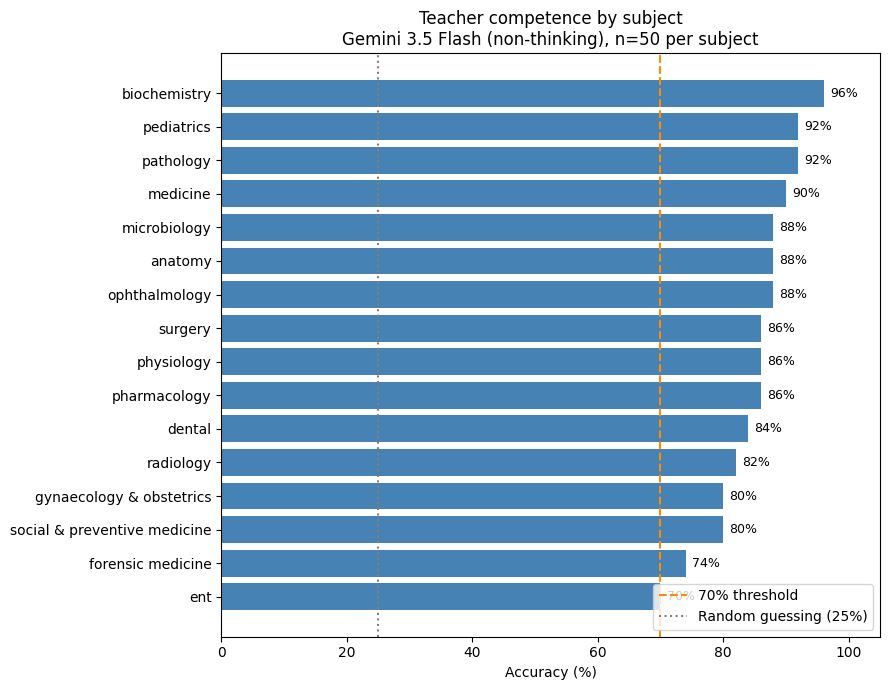

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

s = summary.sort_values('accuracy')          # ascending, so best appears at top
bars = ax.barh(s.index, s['accuracy_pct'], color='steelblue')

# reference lines: your 70% threshold and random-guess baseline
ax.axvline(70, color='darkorange', linestyle='--', linewidth=1.5,
           label='70% threshold')
ax.axvline(25, color='grey', linestyle=':', linewidth=1.5,
           label='Random guessing (25%)')

# value labels on each bar
for bar, val in zip(bars, s['accuracy_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9)

ax.set_xlabel('Accuracy (%)')
ax.set_title(f'Teacher competence by subject\n'
             f'Gemini 3.5 Flash (non-thinking), n=50 per subject')
ax.set_xlim(0, 105)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("competence_by_subject.png", dpi=200)
plt.show()